# Analyse d'erreurs & interprétabilité de modèles

## Vérification de l'utilisation de GPU

Allez dans le menu `Exécution > Modifier le type d'execution` et vérifiez que l'on est bien en Python 3 et que l'accélérateur matériel est configuré sur « GPU ».

In [1]:
!nvidia-smi

Wed Oct  7 11:14:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:04:00.0 Off |                    0 |
| N/A   39C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Téléchargement des données

In [2]:
!wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s landscape

remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 1.94 KiB | 1.94 MiB/s, done.
remote: Enumerating objects: 24289, done.
remote: Counting objects: 100% (24289/24289), done.
remote: Compressing objects: 100% (24289/24289), done.
remote: Total 24289 (delta 0), reused 24289 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24289/24289), 341.65 MiB | 7.01 MiB/s, done.
Updating files: 100% (24336/24336), done.
✓ landscape — 24336 fichiers, 401M


## Import de TensorFlow et des autres librairies nécessaires

In [3]:
!pip install shap
import itertools
import pathlib
import typing

import matplotlib.pyplot as plt
import numpy
import PIL.Image
import seaborn
import shap
import sklearn.metrics
import tensorflow as tf
import tensorflow.keras as keras
import tqdm.notebook

## Préparation des données

Pour charger nos données, nous allons combiner plusieurs librairies : [Pillow](https://pillow.readthedocs.io/) (`PIL`), [NumPy](https://numpy.org/) et [TensorFlow](https://www.tensorflow.org/). Ces librairies seront appelées depuis la fonction `get_images`.

Chaque image est chargée avec PIL puis redimensionnée à 150x150 ; enfin, par défaut, nous retournerons un dataset mélangé grâce à [`tf.random.shuffle`](https://www.tensorflow.org/api_docs/python/tf/random/shuffle).

In [4]:
INPUT_SHAPE = (150, 150)


label_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
label_to_index = {l: i for i, l in enumerate(label_names)}


def get_images(dir_path: pathlib.Path,
               shuffle: bool = True,
               create_labels: bool = True,
               ) -> typing.Tuple[tf.Tensor, tf.Tensor]:
  images = []
  if create_labels:
    labels = []

  # On itère sur les sous-dossier de la racine : ils correspondent chacun à une
  # classe
  for subdir_path in tqdm.notebook.tqdm(
      list(dir_path.iterdir()), desc="Traitement des dossiers"):

    dir_name = subdir_path.name

    if create_labels:
      # On attribue le bon label en fonction du nom du dossier "labels"
      label = label_to_index.get(dir_name)

    # On ajoute chaque image du label (dossier) courant à notre dataset
    for image_path in tqdm.notebook.tqdm(
        list(subdir_path.iterdir()), desc=f"Dossier {dir_name}", leave=False):
      # Utilisation de PIL pour charger l'image
      images.append(
          numpy.array(PIL.Image.open(image_path).resize(INPUT_SHAPE)))
      if create_labels:
        labels.append(label)

  images = tf.constant(numpy.array(images))
  if create_labels:
    labels = tf.constant(numpy.array(labels))

  if shuffle:
    perm = tf.random.shuffle(tf.range(images.shape[0]))
    images = tf.gather(images, perm)
    if create_labels:
      labels = tf.gather(labels, perm)

  if create_labels:
    return images, labels
  else:
    return images

## Appel à `get_images`

In [5]:
images, labels = get_images(pathlib.Path("landscape") / "seg_train")

Traitement des dossiers:   0%|          | 0/6 [00:00<?, ?it/s]

Dossier buildings:   0%|          | 0/2191 [00:00<?, ?it/s]

Dossier forest:   0%|          | 0/2271 [00:00<?, ?it/s]

Dossier glacier:   0%|          | 0/2404 [00:00<?, ?it/s]

Dossier mountain:   0%|          | 0/2512 [00:00<?, ?it/s]

Dossier sea:   0%|          | 0/2274 [00:00<?, ?it/s]

Dossier street:   0%|          | 0/2382 [00:00<?, ?it/s]

Forme des images : (14034, 150, 150, 3)
Forme des labels : (14034,)


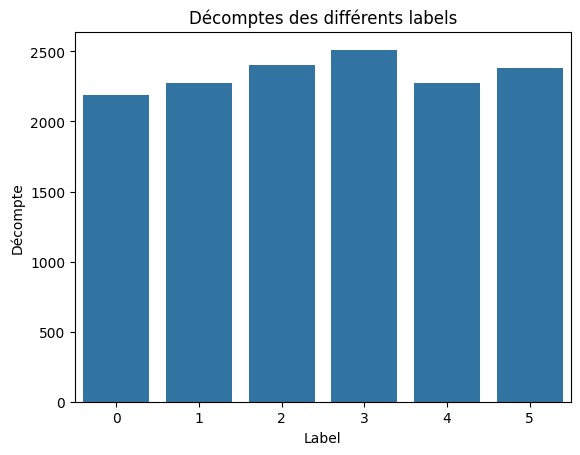

In [6]:
print(f"Forme des images : {images.shape}")
print(f"Forme des labels : {labels.shape}")

seaborn.countplot(x=labels.numpy())
plt.title("Décomptes des différents labels")
plt.ylabel("Décompte")
plt.xlabel("Label")
plt.show()

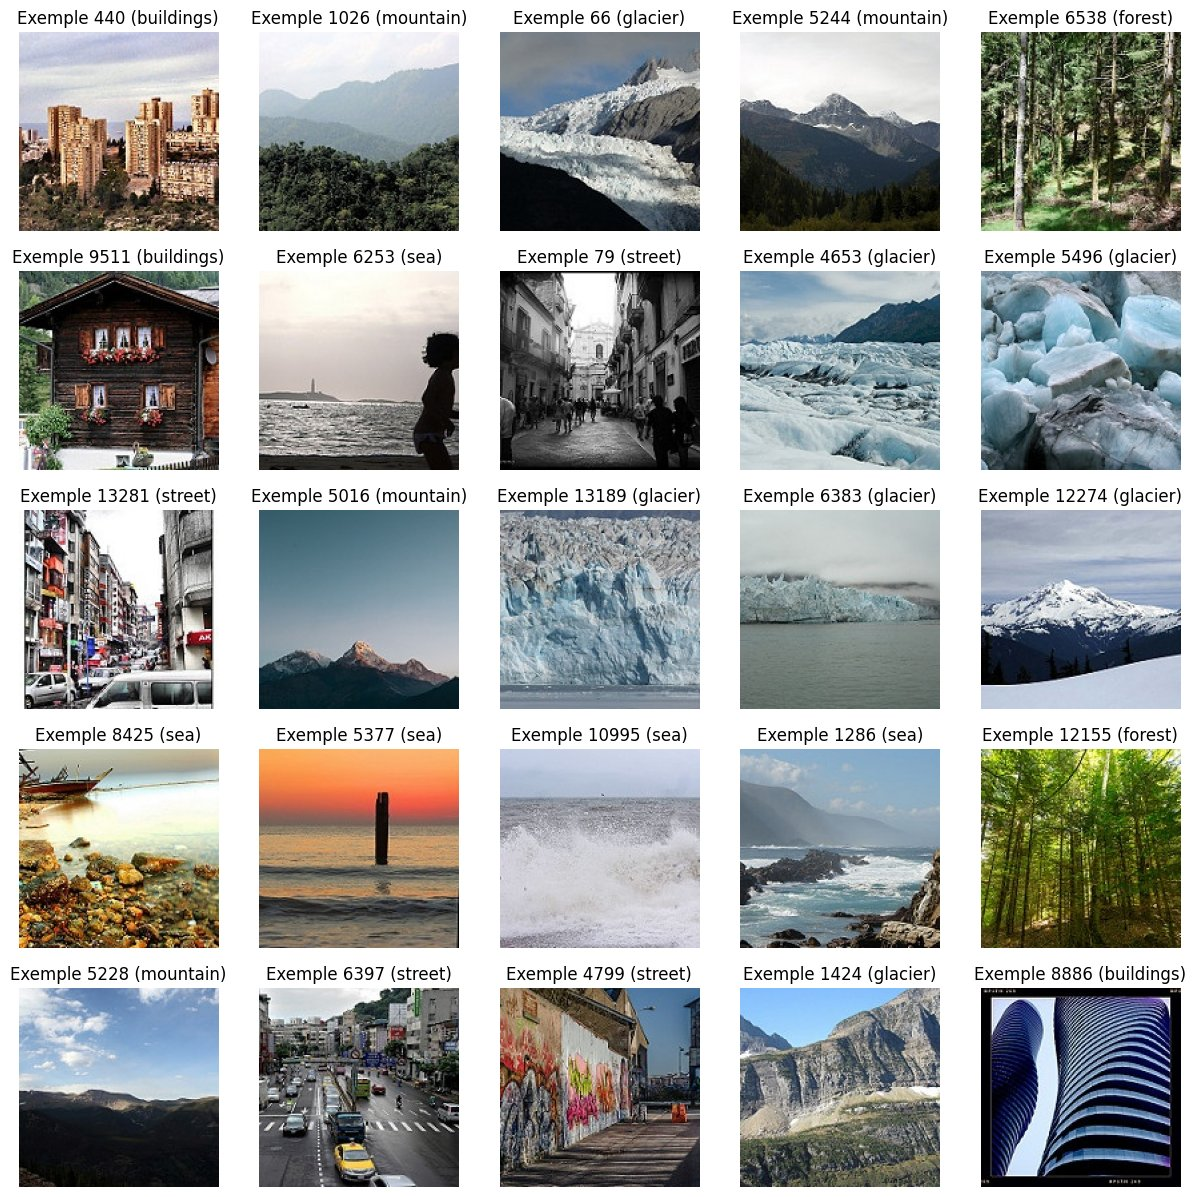

In [7]:
# Création de la grille de sous-plots. On donne l'argument figsize pour agrandir
# la taille de la figure qui est petite par défaut
f, ax = plt.subplots(5, 5, figsize=(15, 15))

# On choisit 25 indices au hasard, sans replacement (on ne veut pas afficher la
# même image deux fois)
random_indexes = numpy.random.choice(images.shape[0],
                                     size=(5, 5),
                                     replace=False)

for i in range(5):
  for j in range(5):
    img_index = random_indexes[i, j]
    image = images[img_index]
    label = label_names[labels[img_index]]

    # Affichage avec matplotlib et sa fonction imshow, très pratique en vision par
    # ordinateur
    ax[i, j].imshow(image)
    ax[i, j].set_title(f"Exemple {img_index} ({label})")
    ax[i, j].axis('off')

## Entraînement d'un modèle peaufiné (*finetuné*)

In [8]:
base_model = keras.applications.EfficientNetB0(include_top=False,
                                               weights="imagenet",
                                               input_shape=(150, 150, 3))

base_model.trainable = False

transferred_cnn = keras.Sequential(
    [base_model,
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(1024, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(256, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(64, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(16, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Flatten(),
     keras.layers.Dense(6, activation="softmax", kernel_regularizer="l2")],
    name="transferred_cnn")

transferred_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                        loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])

transferred_cnn.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "transferred_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 5, 5, 1280)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 1024)     │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 5, 5, 1024)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5, 256)      │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 5, 5, 256)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 5, 5, 64)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 16)       │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 5, 5, 16)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         2,406 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,643,609 (21.53 MB)

 Trainable params: 1,594,038 (6.08 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [9]:
training = transferred_cnn.fit(images,
                               labels,
                               epochs=5,
                               validation_split=0.30,
                               batch_size=512)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step - accuracy: 0.3563 - loss: 1.7870 - val_accuracy: 0.6654 - val_loss: 1.2678
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 356ms/step - accuracy: 0.6609 - loss: 1.0801 - val_accuracy: 0.8076 - val_loss: 0.7190
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms/step - accuracy: 0.7739 - loss: 0.7378 - val_accuracy: 0.8573 - val_loss: 0.5300
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 316ms/step - accuracy: 0.8258 - loss: 0.5969 - val_accuracy: 0.8787 - val_loss: 0.4565
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 314ms/step - accuracy: 0.8555 - loss: 0.5193 - val_accuracy: 0.8884 - val_loss: 0.4178


## Évaluation des performances sur l'ensemble de test

Dans le dossier `seg_test` se trouve un ensemble de données qui n'ont jamais été vues durant l'apprentissage.

On utilisera la méthode `evaluate(X, y)` du modèle pour évaluer la qualité de nos prédictions sur ce dataset.

In [10]:
test_images,test_labels = get_images(
    pathlib.Path("landscape") / "seg_test")

Traitement des dossiers:   0%|          | 0/6 [00:00<?, ?it/s]

Dossier buildings:   0%|          | 0/437 [00:00<?, ?it/s]

Dossier forest:   0%|          | 0/474 [00:00<?, ?it/s]

Dossier glacier:   0%|          | 0/553 [00:00<?, ?it/s]

Dossier mountain:   0%|          | 0/525 [00:00<?, ?it/s]

Dossier sea:   0%|          | 0/510 [00:00<?, ?it/s]

Dossier street:   0%|          | 0/501 [00:00<?, ?it/s]

In [11]:
transferred_cnn.evaluate(test_images, test_labels)

94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 153ms/step - accuracy: 0.8837 - loss: 0.4306


[0.43061327934265137, 0.8836666941642761]

## Analyse d'erreur

On affiche la matrice de confusion puis on regarde des images mal classées.

94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step


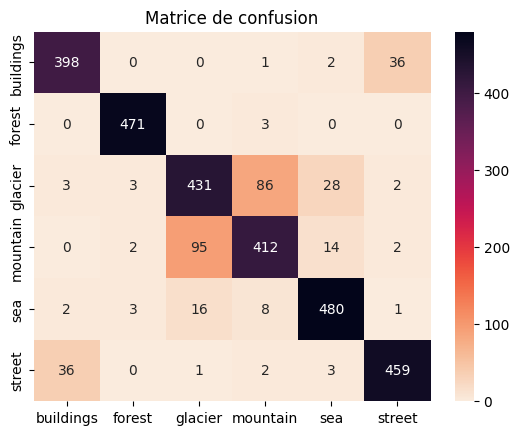

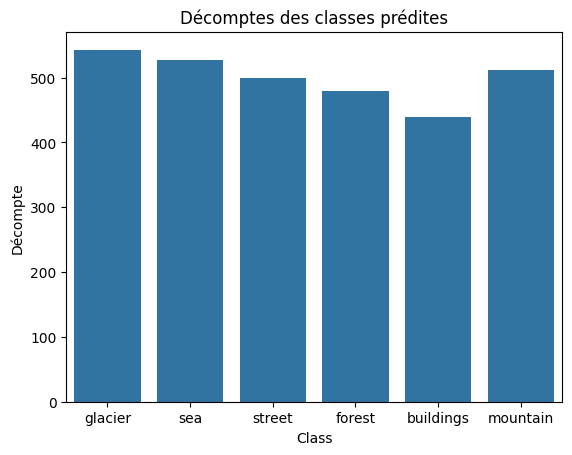

In [12]:
def predict(model: keras.Model, images: tf.Tensor) -> tf.Tensor:
  return tf.math.argmax(model.predict(images), axis=-1)


def analyze_preds(preds: tf.Tensor, labels: tf.Tensor) -> None:
  confusion_matrix = sklearn.metrics.confusion_matrix(labels, preds)
  seaborn.heatmap(confusion_matrix,
                  cmap="rocket_r",
                  xticklabels=label_names,
                  yticklabels=label_names,
                  annot=True,
                  fmt="d")
  plt.title("Matrice de confusion")
  plt.show()

  seaborn.countplot(x=[label_names[x] for x in preds])
  plt.title("Décomptes des classes prédites")
  plt.ylabel("Décompte")
  plt.xlabel("Class")
  plt.show()


test_preds = predict(transferred_cnn, test_images)
analyze_preds(test_preds, test_labels)

In [13]:
def plot_mistakes(predicted_class: str,
                  true_class: str,
                  images: tf.Tensor,
                  preds: tf.Tensor,
                  labels: tf.Tensor
                  ) -> None:
  print(f"Prédiction : {predicted_class}, classe réelle : {true_class}")
  mistakes = images[(preds == label_to_index[predicted_class])
                         & (labels == label_to_index[true_class])]
  random_indexes = numpy.random.choice(mistakes.shape[0],
                                       size=min(mistakes.shape[0], 25),
                                       replace=False)
  grid_indexes = itertools.product(range(5), repeat=2)

  _, ax = plt.subplots(5, 5, figsize=(15, 15))
  for img_index, (i, j) in zip(random_indexes, grid_indexes):
    ax[i, j].imshow(mistakes[img_index])
    ax[i, j].axis("off")
  plt.show()

Prédiction : glacier, classe réelle : mountain


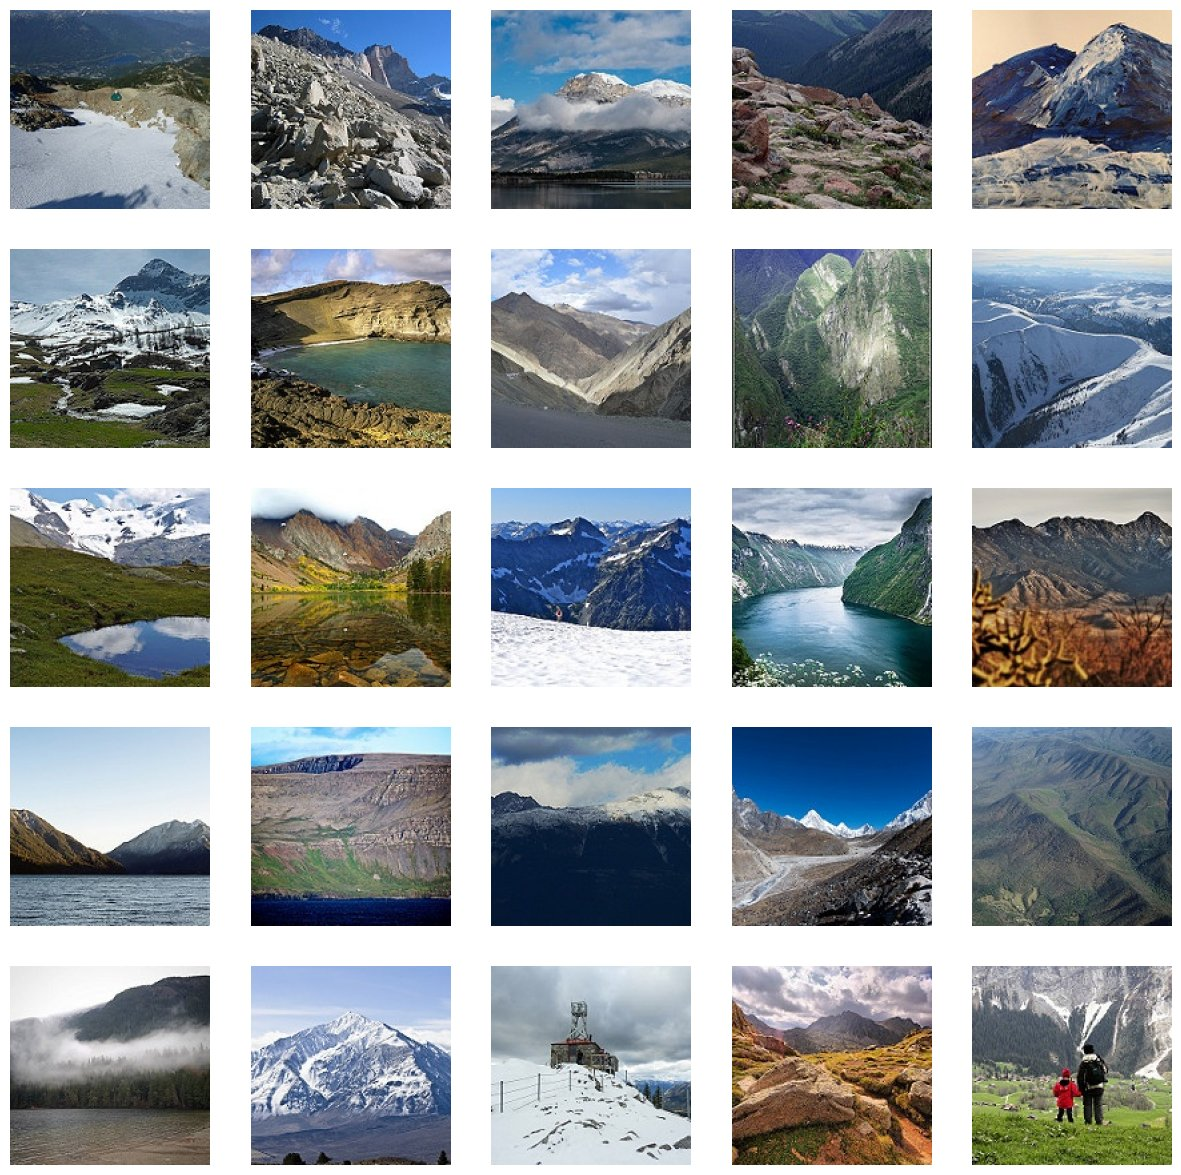

In [14]:
# Plot les images prédites glacier alors qu'elles ont un label montagne
plot_mistakes("glacier", "mountain", test_images, test_preds, test_labels)

Prédiction : glacier, classe réelle : sea


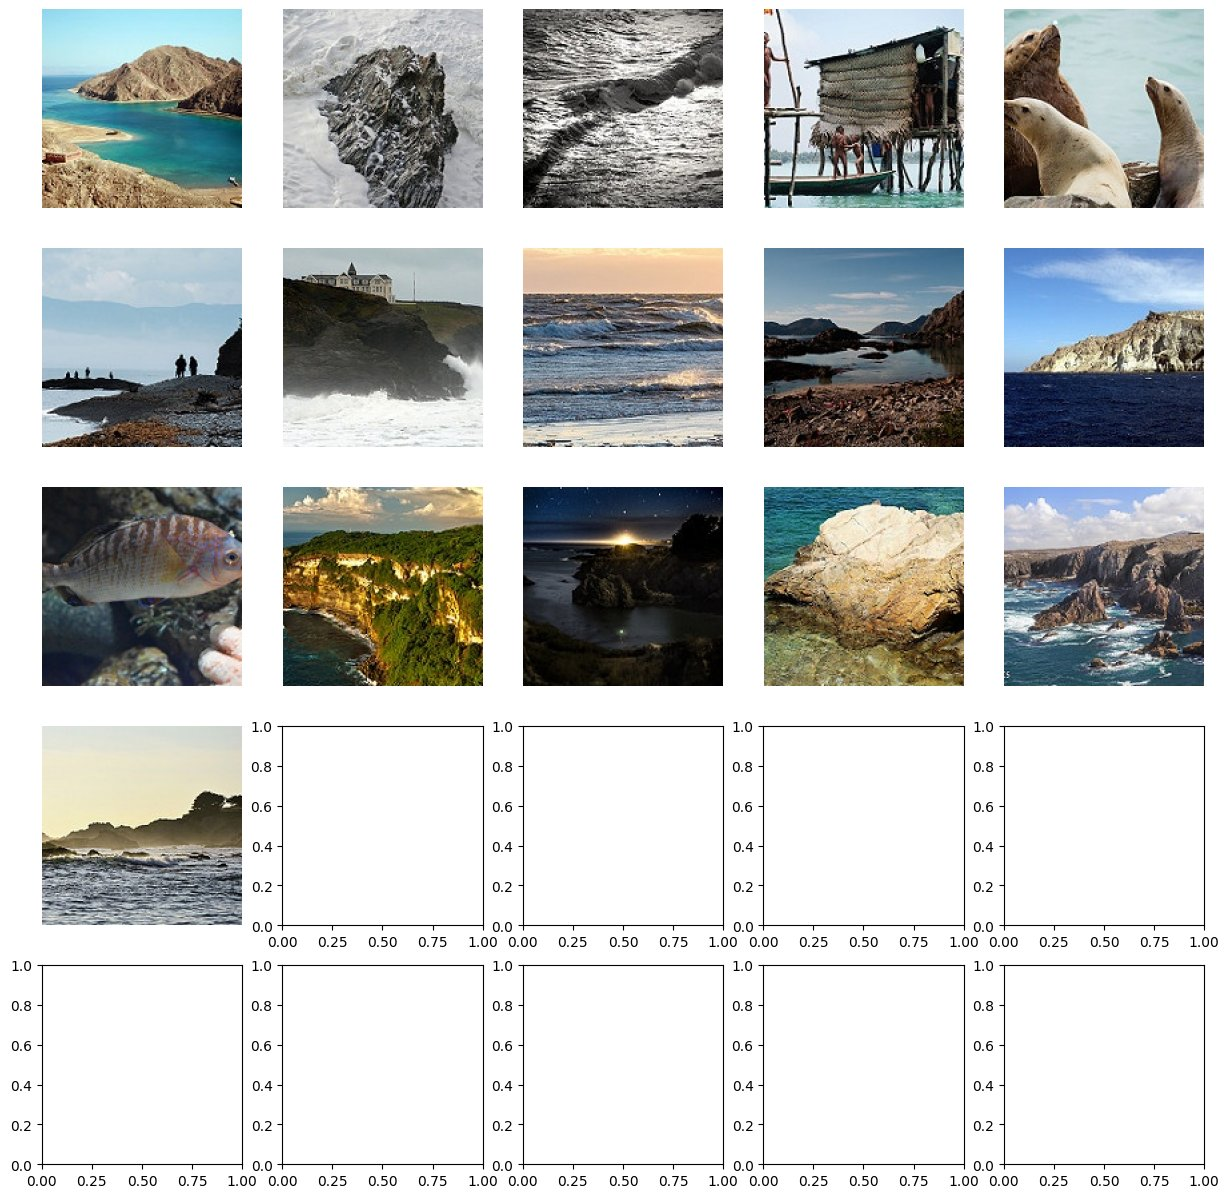

In [15]:
# Plot les images prédites glacier alors qu'elles ont un label mer
plot_mistakes("glacier", "sea", test_images, test_preds, test_labels)

Prédiction : buildings, classe réelle : sea


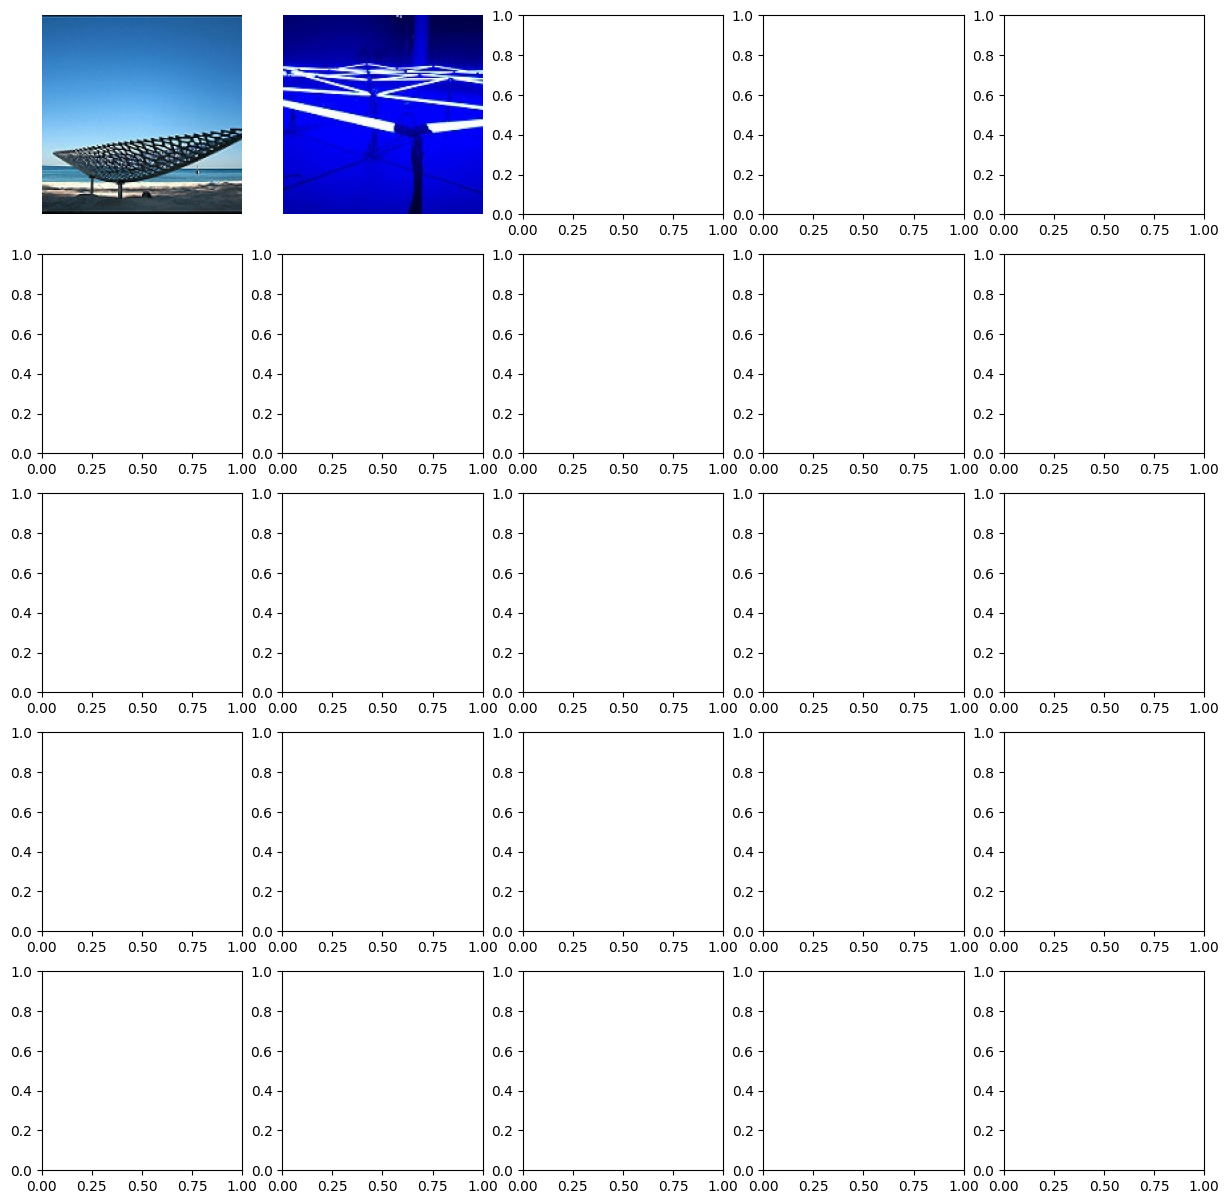

In [16]:
# Plot les images prédites bâtiment alors qu'elles ont un label mer
plot_mistakes("buildings", "sea", test_images, test_preds, test_labels)

Loss: 0.43, accuracy: 0.88
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


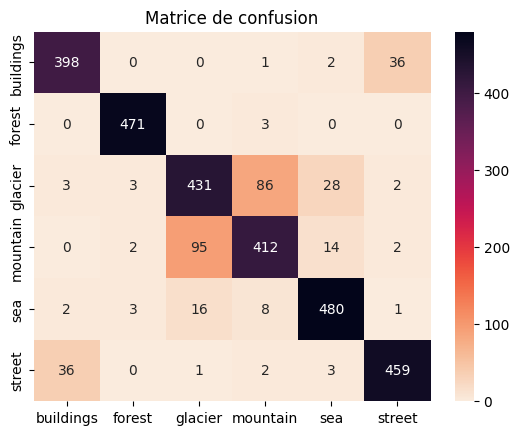

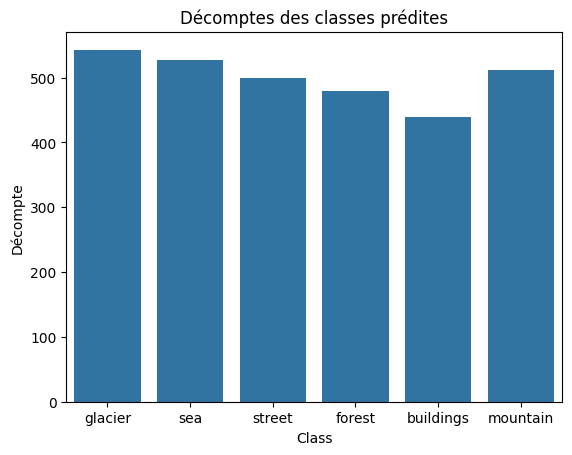

Prédiction : glacier, classe réelle : mountain


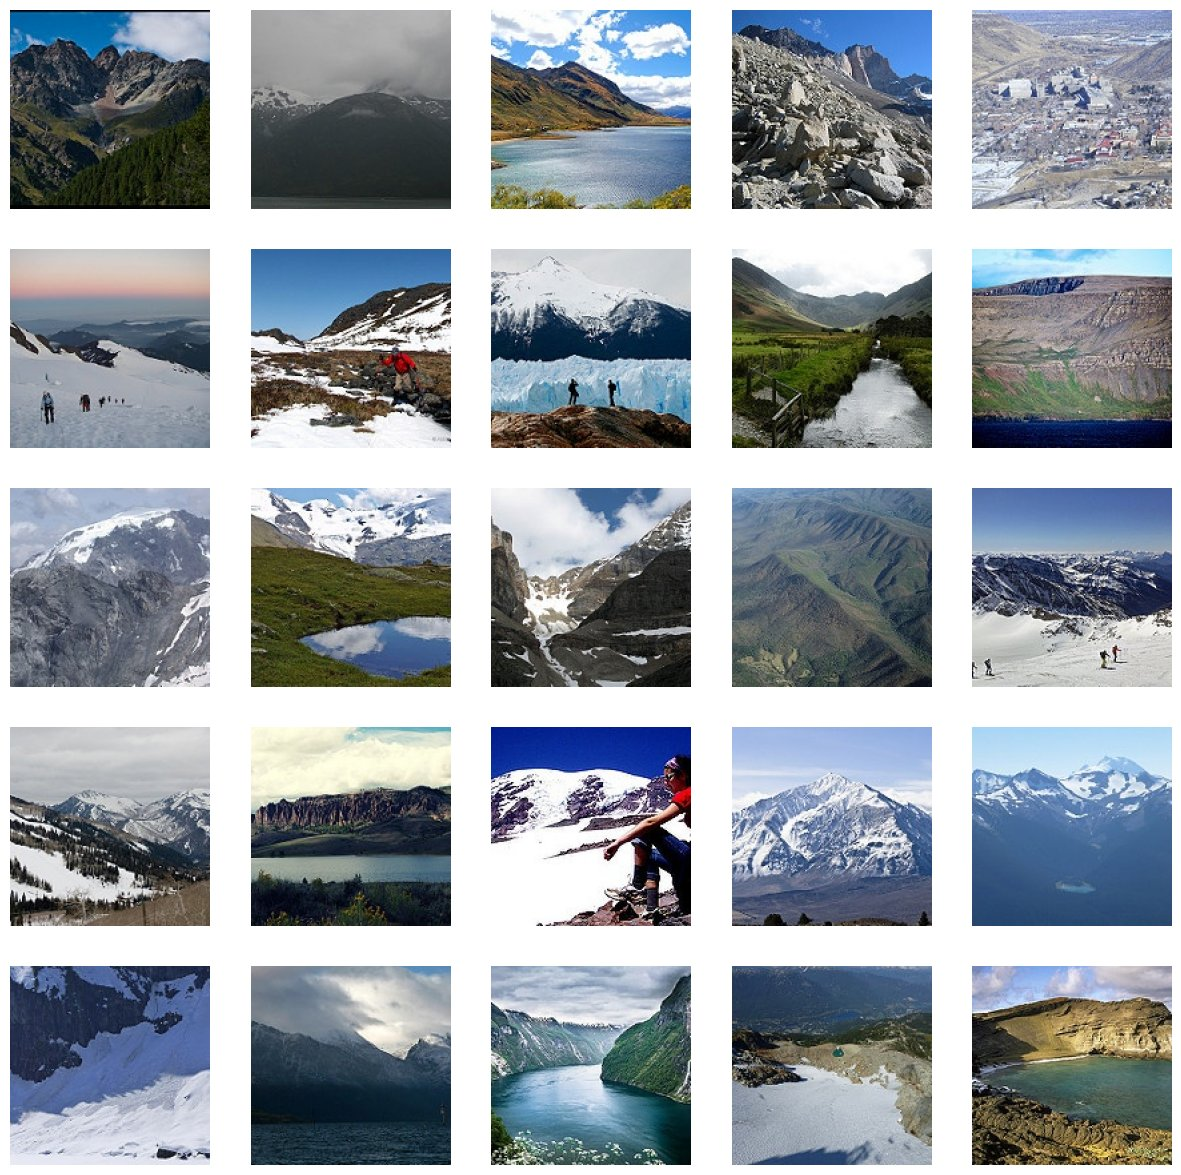

Prédiction : glacier, classe réelle : sea


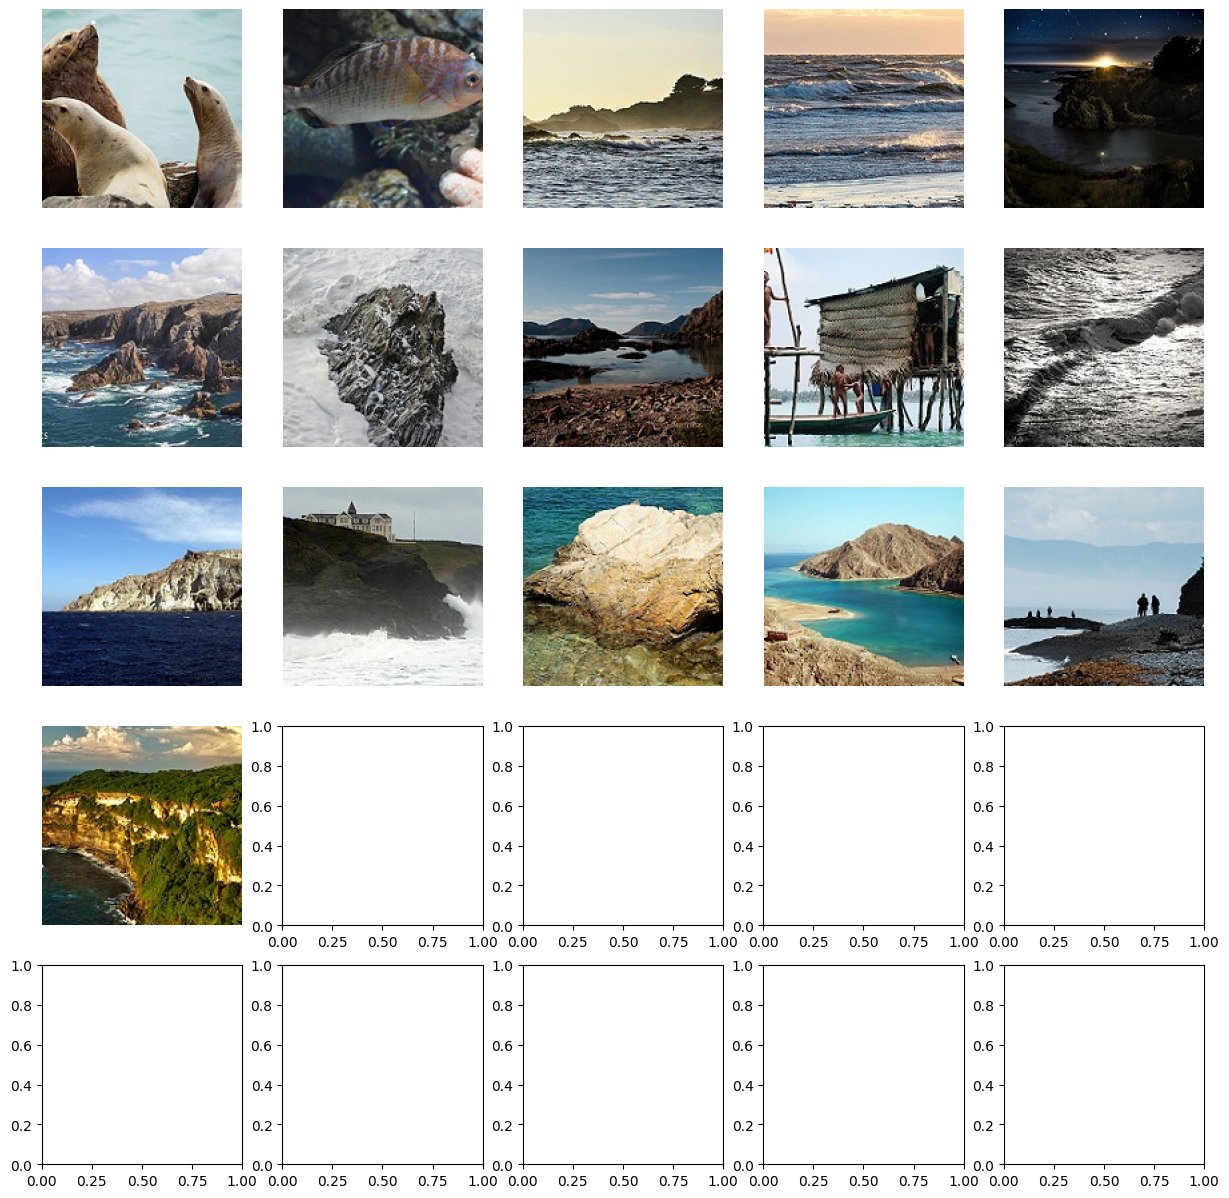

Prédiction : buildings, classe réelle : sea


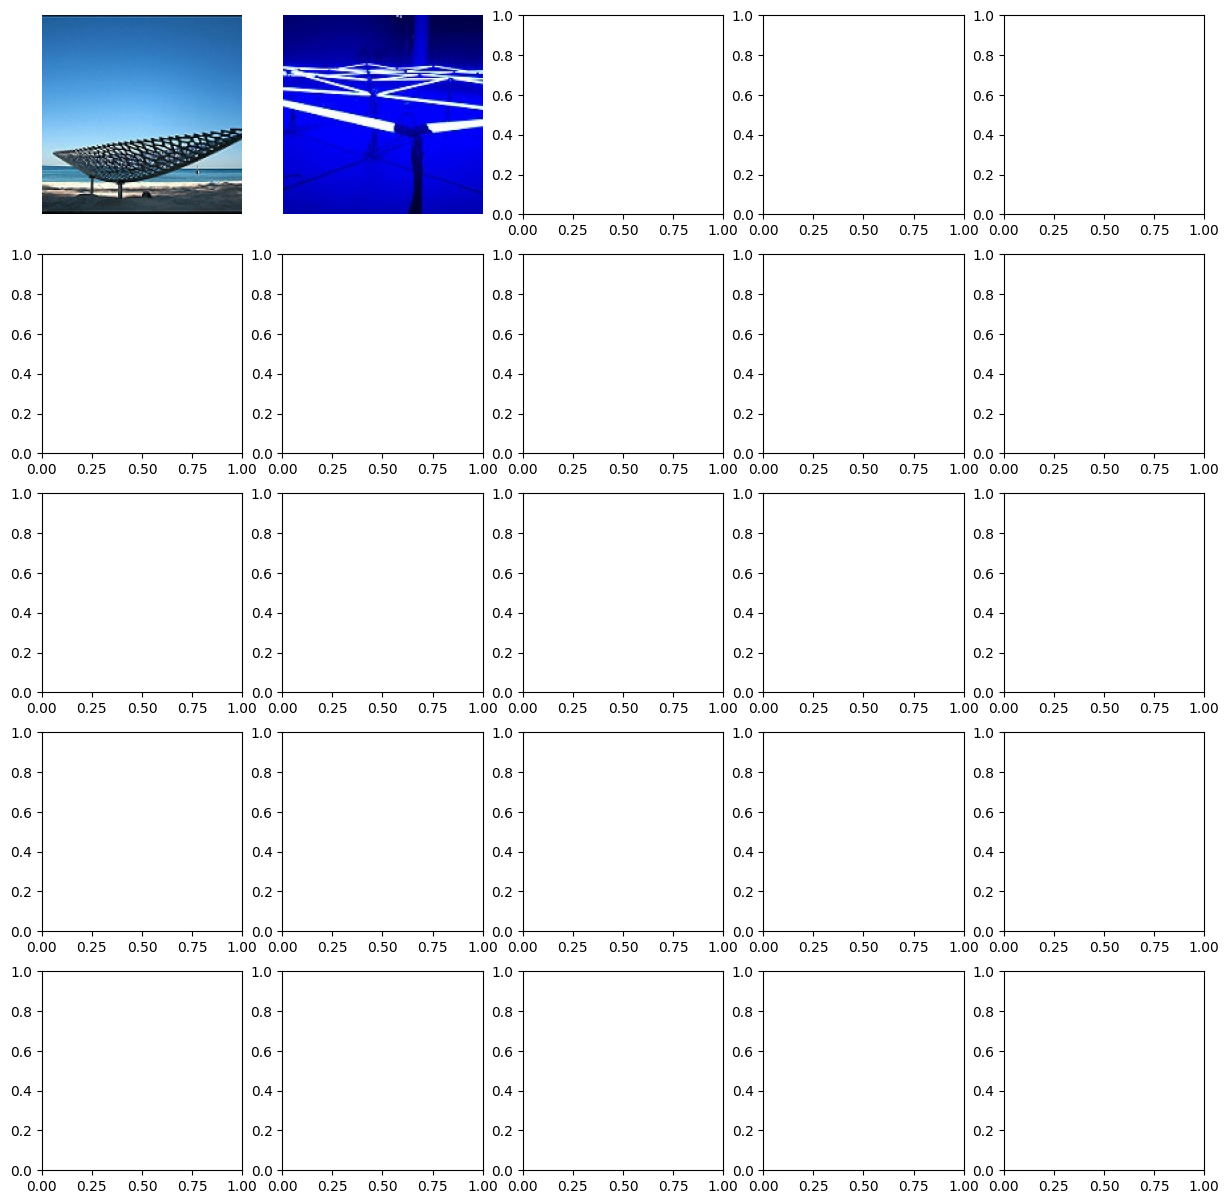

In [17]:
def evaluate(model: keras.Model, images: tf.Tensor, labels: tf.Tensor) -> None:
  loss, accuracy = model.evaluate(images, labels, verbose=False)
  print(f"Loss: {loss:.2f}, accuracy: {accuracy:.2f}")
  preds = predict(model, images)
  analyze_preds(preds, labels)
  plot_mistakes("glacier", "mountain", images, preds, labels)
  plot_mistakes("glacier", "sea", images, preds, labels)
  plot_mistakes("buildings", "sea", images, preds, labels)


evaluate(transferred_cnn, test_images, test_labels)

## Prédire dans des condition « réelles »

Dans le dossier `seg_pred` se trouvent des images non-annotées. On ne peut donc pas évaluer correctement les performances sur cet ensemble.

Cependant, on peut afficher des photos et les probabilités que notre modèle attribue à chaque classe.

In [18]:
pred_images = get_images(
    pathlib.Path("landscape") / "seg_pred",
    create_labels=False)

Traitement des dossiers:   0%|          | 0/1 [00:00<?, ?it/s]

Dossier no_supervision:   0%|          | 0/7301 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


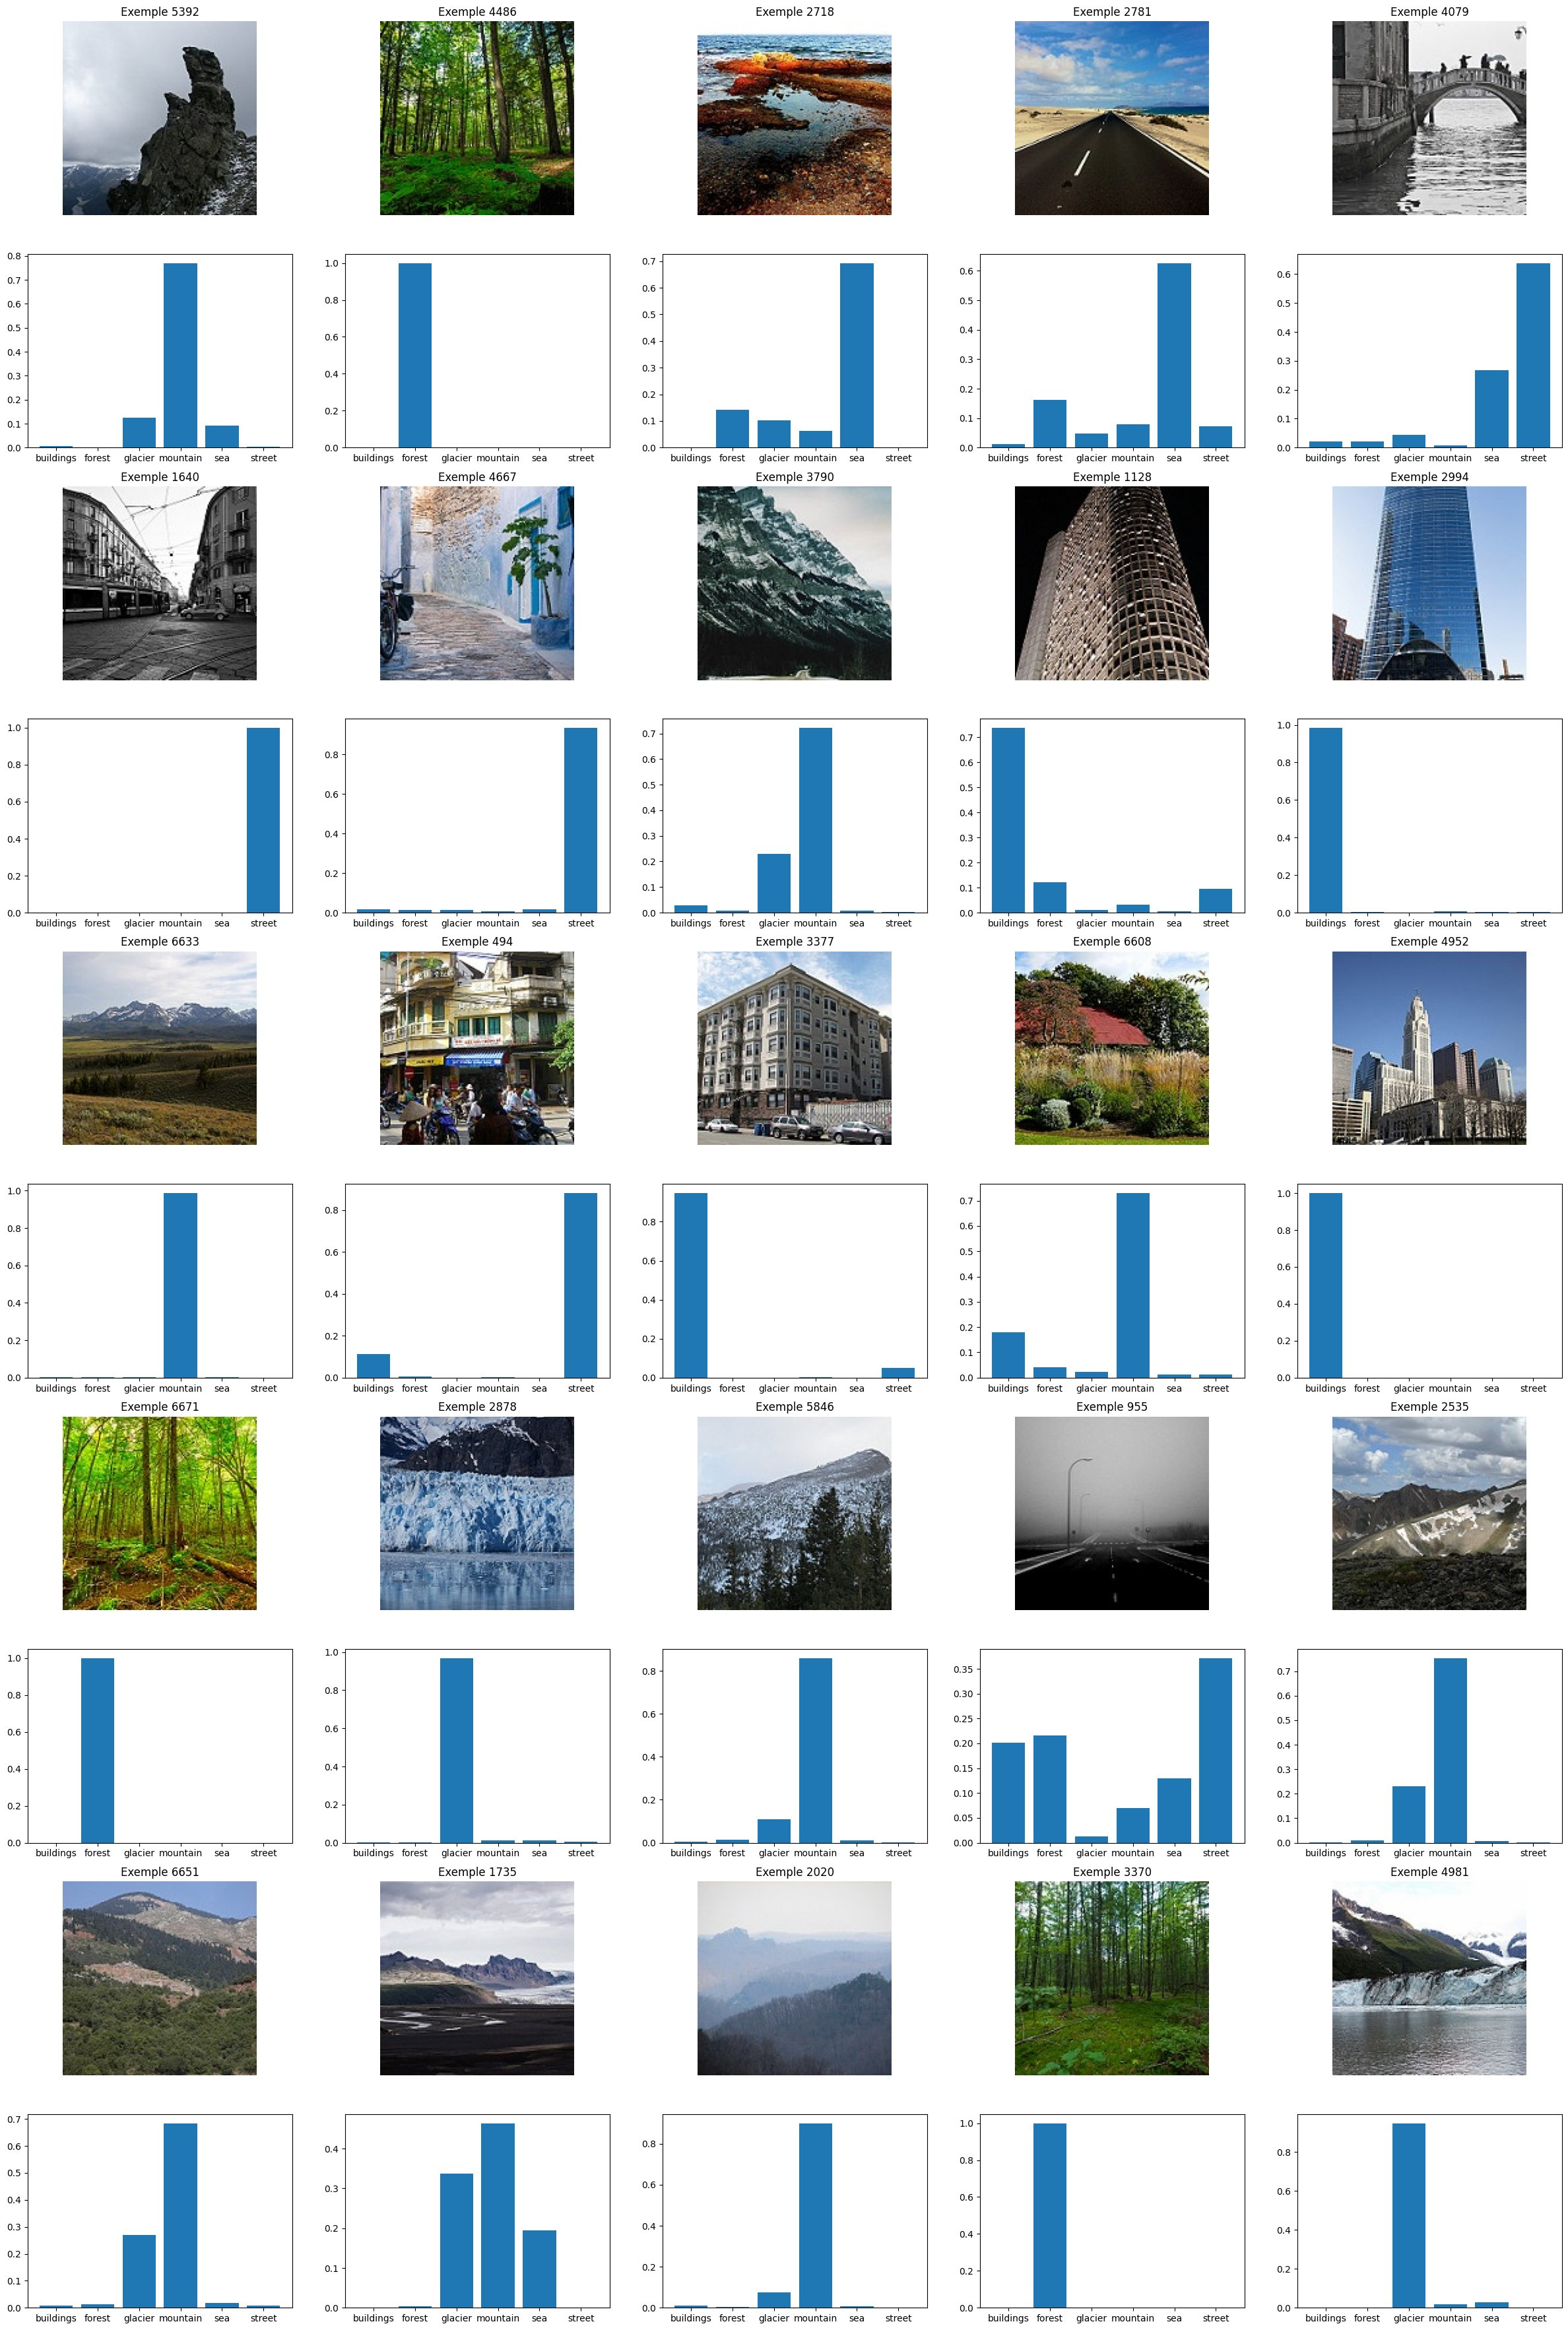

In [19]:
# Création de la grille de sous-plots. On donne l'argument figsize pour agrandir
# la taille de la figure qui est petite par défaut
_, ax = plt.subplots(10, 5, figsize=(30, 45))

# On choisit 25 indices au hasard, sans replacement (on ne veut pas afficher la
# même image deux fois)
random_indexes = numpy.random.choice(pred_images.shape[0],
                                     size=(5, 5),
                                     replace=False)

for i in range(5):
  for j in range(5):
    img_index = random_indexes[i, j]
    # Récupération de l'image et prédiction de sa classe
    image = pred_images[img_index]
    probabilities = transferred_cnn.predict(image[None, ...])[0]
    predicted_class = label_names[numpy.argmax(probabilities)]

    # Affichage avec matplotlib et sa fonction imshow, très pratique en vision
    # par ordinateur
    ax[i * 2, j].imshow(image)
    ax[i * 2, j].set_title(f"Exemple {img_index}")
    ax[i * 2, j].axis('off')

    # Affichage de la distribution de prédiction sur la ligne d'en dessous
    ax[i * 2 + 1, j].bar(label_names, probabilities)

## Interprétabilité de modèle avec SHAP

SHAP (valeurs de Shapley) attribue à chaque variable d'entrée sa contribution à une prédiction : de combien elle a poussé le modèle vers une classe, ou l'en a éloigné. Pour une image, les « variables » sont des zones de l'image : SHAP en floute certaines, regarde comment la prédiction change, et en déduit l'apport de chaque zone. La méthode vient de la théorie des jeux (Lloyd Shapley), où elle sert à répartir un gain entre les joueurs d'une équipe.

Expliquons les erreurs vues plus haut : les montagnes que le modèle a prises pour des glaciers.

In [20]:
# Les images de montagne que le modèle a prises pour des glaciers
glacier_for_mountain = tf.boolean_mask(
    test_images,
    (test_preds == label_to_index["glacier"]) & (test_labels == label_to_index["mountain"]))
print(f"{glacier_for_mountain.shape[0]} montagnes prédites glacier")

masker = shap.maskers.Image("blur(32,32)", test_images[0].shape)

explainer = shap.Explainer(transferred_cnn.predict, masker, output_names=label_names)

# On explique les deux classes en jeu : « glacier » (prédite) et « mountain » (réelle)
shap_values = explainer(
    glacier_for_mountain[:6].numpy(), max_evals=1_000, batch_size=50,
    outputs=[label_to_index["glacier"], label_to_index["mountain"]]
)

95 montagnes prédites glacier
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


  0%|          | 0/998 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


PartitionExplainer explainer:  17%|█▋        | 1/6 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


...

PartitionExplainer explainer:  83%|████████▎ | 5/6 [01:34<00:03,  3.80s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


PartitionExplainer explainer: 100%|██████████| 6/6 [01:39<00:00,  4.12s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


PartitionExplainer explainer: 7it [01:44, 17.42s/it]


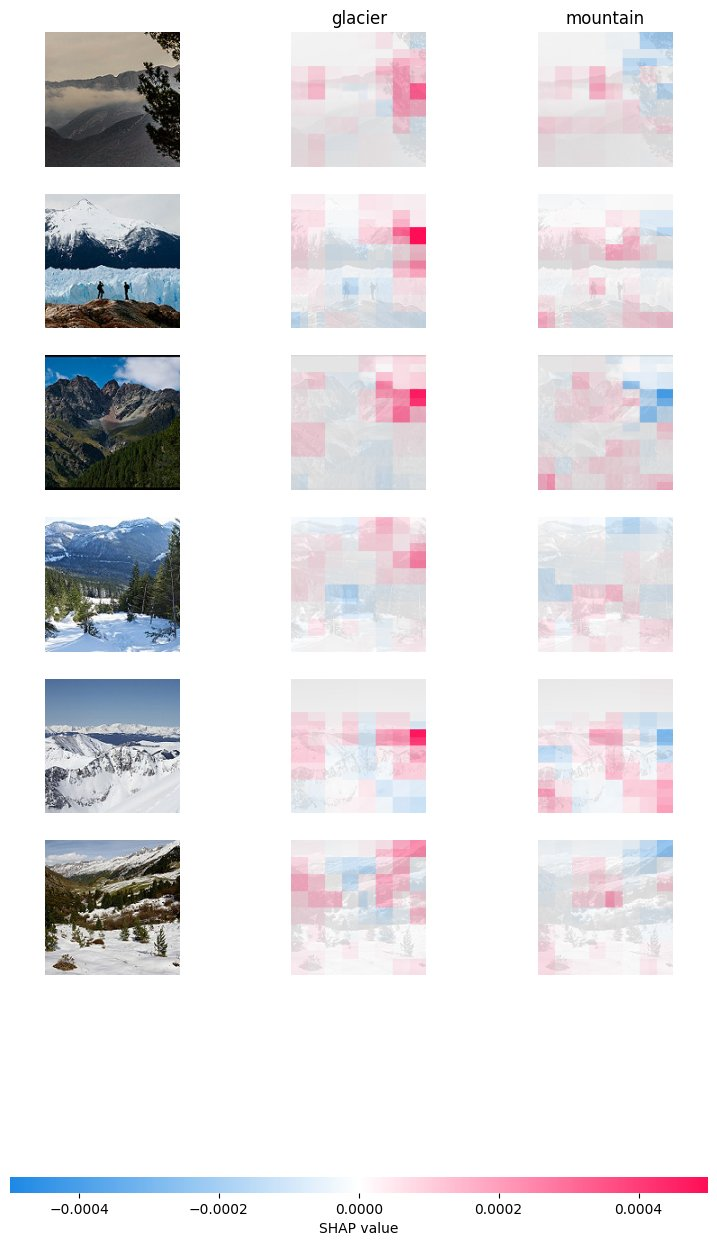

In [21]:
shap.image_plot(shap_values)

Comment lire la figure : chaque ligne est une image mal classée. La colonne « glacier » montre les zones qui ont poussé le modèle vers « glacier » (en rouge) ou l'en ont éloigné (en bleu) ; la colonne « mountain » fait de même pour la vraie classe.

**Questions :**

- Quelles zones des images ont poussé le modèle vers « glacier » ?
- Pour chaque image, l'erreur vient-elle plutôt du modèle, ou de l'annotation (une image qu'un humain hésiterait aussi à classer) ?

### Éléments de réponse

- Dans la colonne « glacier », le rouge se concentre dans le haut des images : les sommets et les crêtes, souvent enneigés, qui se découpent sur le ciel. Le bas des images (forêt, rochers, bâtiments) pèse peu, ou éloigne de « glacier ». Le modèle associe « glacier » aux reliefs clairs sur fond de ciel, que l'on retrouve sur les montagnes enneigées.
- Beaucoup de ces « montagnes » sont des sommets enneigés, voire des glaciers de montagne : un humain hésiterait aussi. Les deux classes se recouvrent, et rien dans les données ne dit où passe la frontière. C'est un problème d'annotation : on le traite en précisant le guide d'annotation (par exemple « glacier si la glace occupe l'essentiel de l'image ») et en ré-annotant les cas ambigus, pas en changeant de modèle.
- Si les zones rouges tombent sur un détail sans rapport (un bord de l'image, un ciel uniforme), c'est le modèle qui s'appuie sur un mauvais indice : il faut des exemples plus variés (ou de l'augmentation de données), ou un meilleur modèle. Ce n'est pas le cas ici : les zones rouges tombent bien sur le relief.
- Limites : SHAP floute des carrés de l'image, son explication est donc grossière (des blocs, pas des contours). Et six images ne suffisent pas : on en regarde plusieurs avant de conclure.

## SHAP sur des données structurées

Changeons de problème : prédire le prix de vente de maisons d'Ames (Iowa, États-Unis) d'après leurs caractéristiques (surface, qualité, quartier…). Commençons par récupérer les données, puis entraînons une forêt aléatoire en gardant 20 % des maisons de côté, pour mesurer ses erreurs sur des maisons qu'elle n'a jamais vues :

In [22]:
#@title Récupération des données et fonction de prétraitement
!wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s ames
import pandas
import numpy
import matplotlib.pyplot as plt
import seaborn
import sklearn.ensemble
import sklearn.model_selection
import scipy.stats
import warnings
warnings.filterwarnings('ignore')

def preprocess(train_file, test_file):
    train_X = pandas.read_csv(train_file, index_col="Id")
    test_X = pandas.read_csv(test_file, index_col="Id")

    train_y = train_X.pop("SalePrice")

    all_X = pandas.concat([train_X, test_X])

    # Fill with median
    cols_1 = ["LotFrontage"]
    all_X[cols_1] = all_X[cols_1].fillna(train_X[cols_1].median())

    # Fill with mode
    cols_2 = ["MSZoning", "Electrical", "KitchenQual", "Exterior1st",
             "Exterior2nd", "SaleType", "Utilities"]
    all_X[cols_2] = all_X[cols_2].fillna(train_X[cols_2].mode().iloc[0, :])

    # Fill with 0
    cols_4 = ["GarageYrBlt", "GarageArea", "GarageCars", "BsmtFinSF1",
              "BsmtFinSF2", "BsmtFullBath", "BsmtHalfBath", "BsmtUnfSF",
              "MasVnrArea", "TotalBsmtSF"]
    all_X[cols_4] = all_X[cols_4].fillna(0)

    # Other fills
    cols_5 = ["Functional"]
    all_X[cols_5] = all_X[cols_5].fillna("Typ")

    # On donne à tous les autres NAs la valeur string NA, qui sera une catégorie
    all_X = all_X.fillna("NA")

    # On transforme le codage numérique en string afin que ce soit traité comme
    # une variable catégorielle
    cols_numerical2label = ['MSSubClass']
    all_X[cols_numerical2label] = all_X[cols_numerical2label].astype(str)

    quality_mapping = dict(NA=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5)
    quality_columns = ["BsmtCond", "BsmtQual", "ExterCond", "ExterQual",
                       "FireplaceQu", "GarageCond", "GarageQual", "HeatingQC",
                       "KitchenQual", "PoolQC"]
    street_mapping = dict(NA=0, Grvl=1, Pave=2)
    bsmt_fin_mapping = dict(NA=0, Unf=1, LwQ=2, Rec=3, BLQ=4, ALQ=5, GLQ=6)

    replace_mapping = dict(
      Alley=street_mapping,
      BsmtExposure=dict(NA=0, No=1, Mn=2, Av=3, Gd=4),
      BsmtFinType1=bsmt_fin_mapping,
      BsmtFinType2=bsmt_fin_mapping,
      Functional=dict(Sal=1, Sev=2, Maj2=3, Maj1=4, Mod=5, Min2=6, Min1=7, Typ=8),
      LandSlope=dict(Sev=1, Mod=2, Gtl=3),
      LotShape=dict(IR3=1, IR2=2, IR1=3, Reg=4),
      PavedDrive=dict(NA=0, N=1, P=2, Y=3),
      Street=dict(Grvl=1, Pave=2),
      Utilities=dict(ELO=1, NoSeWa=2, NoSewr=3, AllPub=4),
    )

    for quality_column in quality_columns:
      replace_mapping[quality_column] = quality_mapping

    all_X.replace(replace_mapping, inplace=True)

    print(f"Nombre de NAs : {all_X.isnull().sum().sum()}")

    dummies = pandas.get_dummies(all_X)
    return (dummies.iloc[:train_X.shape[0], :],
            train_y,
            dummies.iloc[train_X.shape[0]:, :])

remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 1.94 KiB | 1.94 MiB/s, done.
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 8 (delta 2), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 422.90 KiB | 2.34 MiB/s, done.
Resolving deltas: 100% (2/2), done.
✓ ames — 8 fichiers, 4.6M


In [23]:
X, y, _ = preprocess("ames/train.csv", "ames/test.csv")

Nombre de NAs : 0


In [24]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.2, random_state=0)
rfr = sklearn.ensemble.RandomForestRegressor(random_state=0, n_jobs=-1)
rfr.fit(X_train, y_train)

errors = (y_test - rfr.predict(X_test)).abs()
print(f"Erreur moyenne sur les maisons de test : {errors.mean():,.0f} $ "
      f"(prix moyen : {y_test.mean():,.0f} $)")

Erreur moyenne sur les maisons de test : 17,065 $ (prix moyen : 181,370 $)


## Explication globale

On calcule les valeurs de Shapley de chaque variable pour chaque maison de test, puis leur moyenne (en valeur absolue) : c'est l'importance globale de la variable pour le modèle.

In [25]:
explainer = shap.TreeExplainer(rfr)
explanation = explainer(X_test)

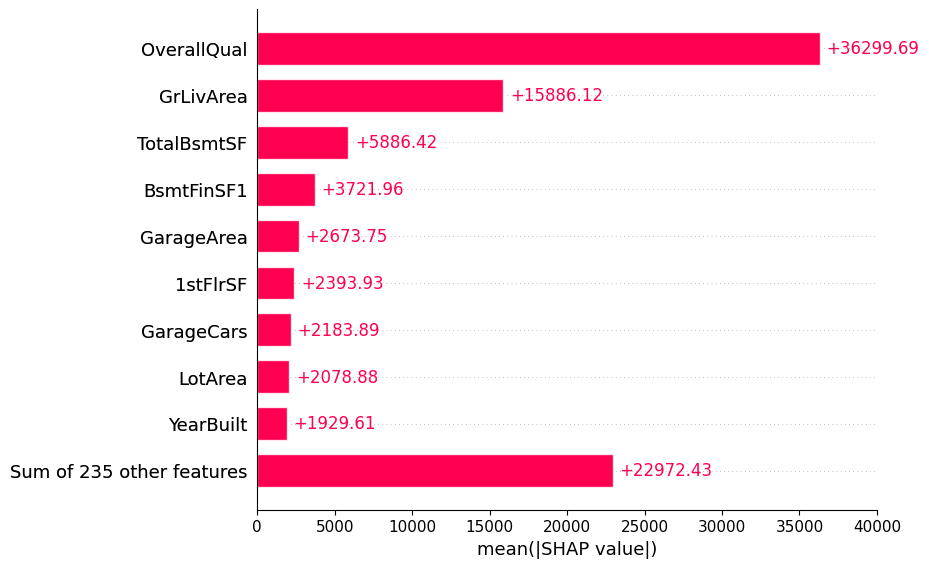

In [26]:
shap.plots.bar(explanation)

**Question :** quelles sont les 3 variables les plus importantes ? Ont-elles du sens pour le prix d'une maison ?

### Éléments de réponse

- `OverallQual` (la qualité générale de la maison, une note de 1 à 10 donnée par un évaluateur), `GrLivArea` (la surface habitable) et `TotalBsmtSF` (la surface du sous-sol) : la qualité et la surface. C'est cohérent avec ce qu'on sait du prix d'un bien immobilier.
- `OverallQual` écrase les autres : cette note résume déjà beaucoup de choses (matériaux, finitions…). Il faut vérifier qu'elle sera disponible au moment de prédire : si le modèle doit estimer une annonce en ligne, sans évaluation, il perd sa variable principale.
- Une variable catégorielle, comme le quartier, est découpée en une colonne 0/1 par valeur (`Neighborhood_...`) : son importance se répartit entre ces colonnes, il faut les additionner pour la juger.
- SHAP explique le modèle, pas le marché : une variable importante pour le modèle n'est pas forcément une cause du prix.

## Explication locale

Comparons la maison de test que le modèle prédit le plus mal à une maison qu'il prédit bien. Pour une maison, SHAP part du prix moyen prédit (en bas du graphique, $E[f(X)]$) et ajoute la contribution de chaque variable (en rouge si elle fait monter le prix, en bleu si elle le fait baisser), jusqu'au prix prédit (en haut, $f(x)$).

Maison 1299 : prix réel 160,000 $, prix prédit 481,143 $


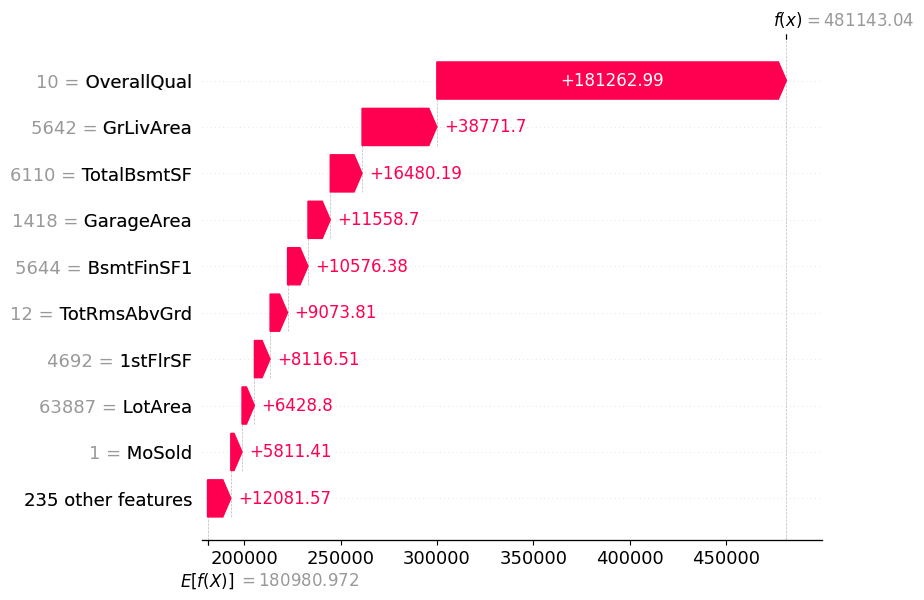

In [27]:
def explain_house(house_id: int) -> None:
  position = X_test.index.get_loc(house_id)
  print(f"Maison {house_id} : prix réel {y_test[house_id]:,.0f} $, "
        f"prix prédit {rfr.predict(X_test.iloc[[position]])[0]:,.0f} $")
  shap.plots.waterfall(explanation[position])


worst = errors.idxmax()
explain_house(worst)

Maison 460 : prix réel 110,000 $, prix prédit 110,042 $


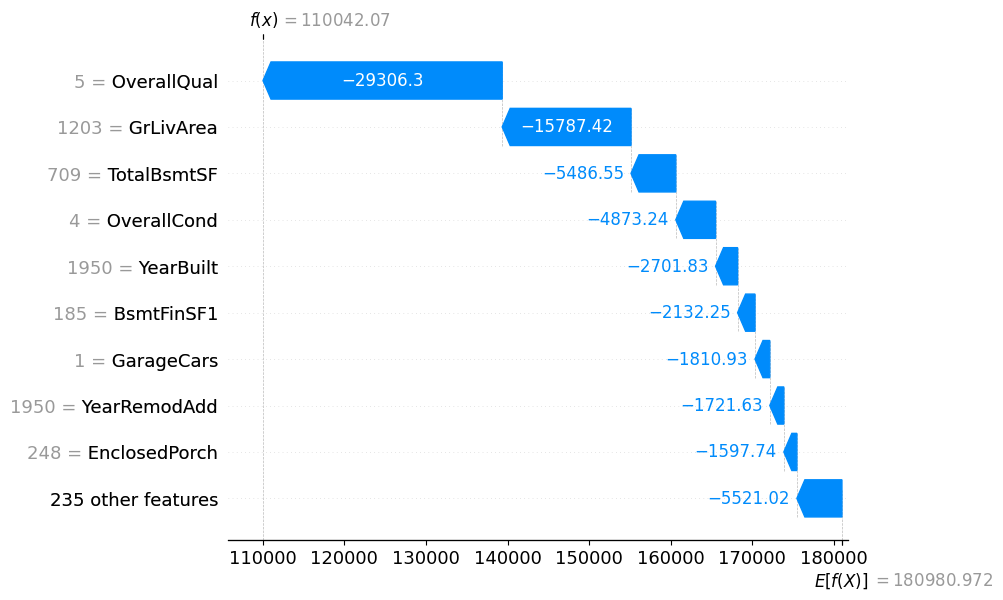

In [28]:
well_predicted = errors.idxmin()
explain_house(well_predicted)

In [29]:
# Quelques colonnes des données d'origine, avant prétraitement
raw = pandas.read_csv("ames/train.csv", index_col="Id")
raw.loc[[worst, well_predicted],
        ["OverallQual", "GrLivArea", "TotalBsmtSF", "LotArea", "SaleCondition", "SalePrice"]]

,OverallQual,GrLivArea,TotalBsmtSF,LotArea,SaleCondition,SalePrice
Id,,,,,,
1299,10,5642,6110,63887,Partial,160000
460,5,1203,709,7015,Normal,110000


**Questions :**

- Pourquoi le modèle se trompe-t-il autant sur la première maison ? Est-ce un problème du modèle ou des données ?
- Qu'est-ce qui distingue l'explication de la maison bien prédite ?

### Éléments de réponse

- La maison la plus mal prédite (la n° 1299) a tout d'une maison très chère : qualité maximale (10), plus de 5 600 pieds carrés habitables (environ 520 m²), un sous-sol et un terrain immenses. SHAP montre que `OverallQual` et `GrLivArea` font monter sa prédiction de plus de 200 000 \$ au-dessus de la moyenne : le modèle a raisonné « normalement ».
- Elle s'est pourtant vendue 160 000 \$ : c'est une vente partielle (`SaleCondition = Partial`, une maison neuve vendue avant d'être achevée). L'auteur du jeu de données, Dean De Cock, signale lui-même ces quelques très grandes maisons atypiques et conseille de les écarter. C'est un problème de données, pas de modèle : on vérifie la donnée, puis on l'exclut ou on ajoute l'information qui manque, plutôt que de modifier le modèle.
- La maison bien prédite (la n° 460, vendue 110 000 \$) est une maison modeste : qualité moyenne (5), 1 200 pieds carrés habitables (environ 110 m²). Les mêmes variables, `OverallQual` et `GrLivArea` en tête, font cette fois baisser sa prédiction, et toutes les contributions vont dans le même sens, sans valeur extrême : un profil courant dans les données, que le modèle connaît bien.
- Méthode générale : examiner les plus grosses erreurs une par une, avec leur explication. Elles révèlent souvent des données aberrantes ou mal saisies.

## À retenir

- L'analyse d'erreurs commence par la matrice de confusion, puis par l'examen des exemples mal classés : c'est là qu'on découvre si le problème vient du modèle ou des données.
- SHAP (valeurs de Shapley) explique une prédiction : la contribution de chaque variable, ou de chaque zone d'une image. Leur moyenne sur beaucoup d'exemples donne l'importance globale des variables.
- Une explication sert à vérifier que le modèle s'appuie sur des indices sensés, et à repérer des variables indisponibles en production ou des données aberrantes.
- SHAP explique le modèle, pas la réalité : une variable importante n'est pas forcément une cause.
- Beaucoup d'erreurs viennent des étiquettes ou des données (classes qui se recouvrent, ventes atypiques) : on les corrige dans les données et dans le guide d'annotation, pas en changeant de modèle.